# Multi-Label CLIP Recommendation Ranking

## 1. Objective

The objective of this experiment is to improve outfit recommendations by combining multi-label style prediction with CLIP visual similarity ranking.

The previous experiment showed that simply allowing multiple styles into the recommendation pool did not improve recommendations. The new multi-style mode sometimes selected items from different aesthetics that did not work well together visually.

This experiment tests a better approach:

- use the multi-label style prediction to define possible style directions
- use CLIP visual similarity to rank candidate items
- recommend the most visually compatible items instead of selecting randomly

The main research question is:

**Does combining multi-label style prediction with CLIP ranking improve outfit recommendation coherence compared with random multi-style selection?**

## 2. Experiment Design

This experiment compares two recommendation approaches.

| Mode | Description |
|---|---|
| Previous multi-style mode | Filters by multi-label styles, then randomly selects items |
| New multi-style + CLIP mode | Filters by multi-label styles, then ranks items using CLIP visual similarity |

The same 16 evaluation examples from the previous recommendation experiment are reused.

The expected improvement is not classification accuracy. The expected improvement is better recommendation quality, especially:

- better visual coherence
- better overall outfit quality
- fewer random-looking item combinations

## 3. Imports and setup

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn.functional as F

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
    print("GPU:", torch.cuda.get_device_name(0))
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

print("Torch version:", torch.__version__)

Using device: CUDA
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Torch version: 2.11.0+cu130


## 4. Paths

In [2]:
# Inputs from previous experiments
selected_examples_path = Path(
    "../results/multilabel_recommendation_evaluation/recommendation_evaluation_examples_16.csv"
)

previous_random_recommendations_path = Path(
    "../results/multilabel_recommendation_evaluation/recommendation_comparison_old_vs_new.csv"
)

catalogue_root = Path("../dataset/cleaned")

# Output folder
results_dir = Path("../results/multilabel_clip_recommendation_ranking")
results_dir.mkdir(parents=True, exist_ok=True)

manual_review_dir = results_dir / "manual_review"
manual_review_dir.mkdir(parents=True, exist_ok=True)

visual_sheet_dir = manual_review_dir / "visual_clip_comparison_sheets"
visual_sheet_dir.mkdir(parents=True, exist_ok=True)

print("Selected examples file exists:", selected_examples_path.exists())
print("Previous random recommendations file exists:", previous_random_recommendations_path.exists())
print("Catalogue folder exists:", catalogue_root.exists())
print("Results folder:", results_dir)

Selected examples file exists: True
Previous random recommendations file exists: True
Catalogue folder exists: True
Results folder: ..\results\multilabel_clip_recommendation_ranking


## 5. Load Evaluation Examples

This experiment reuses the same 16 examples from the previous recommendation evaluation.

This keeps the comparison fair, because the input images stay exactly the same.

In [4]:
evaluation_examples_df = pd.read_csv(selected_examples_path)

print("Evaluation examples:", len(evaluation_examples_df))
print("Columns:", evaluation_examples_df.columns.tolist())

target_types = ["jacket", "pants", "shoes", "tshirt"]

def infer_input_type_from_path(image_path):
    normalized_path = str(image_path).replace("\\", "/")
    path_parts = Path(normalized_path).parts

    for item_type in target_types:
        if item_type in path_parts:
            return item_type

    return "unknown"


# Add input_type if it is missing
if "input_type" not in evaluation_examples_df.columns:
    evaluation_examples_df["input_type"] = evaluation_examples_df["image_path"].apply(
        infer_input_type_from_path
    )

display(
    evaluation_examples_df[
        [
            "evaluation_id",
            "filename",
            "true_style",
            "input_type",
            "predicted_main_style",
            "predicted_styles_threshold_fallback",
            "image_path"
        ]
    ]
)

Evaluation examples: 16
Columns: ['source', 'split', 'filename', 'image_path', 'true_style', 'type', 'label_formal', 'label_gothic', 'label_sporty', 'label_streetwear', 'predicted_main_style', 'predicted_styles_threshold_fallback', 'predicted_label_count', 'score_formal', 'score_gothic', 'score_sporty', 'score_streetwear', 'top1_correct', 'evaluation_id']


,evaluation_id,filename,true_style,input_type,predicted_main_style,predicted_styles_threshold_fallback,image_path
0,eval_01,formal_jacket_rw_003.png,formal,jacket,streetwear,formal + streetwear,..\dataset\real_world_test\formal\jacket\forma...
1,eval_02,formal_tshirt_rw_002.png,formal,tshirt,streetwear,formal + streetwear,..\dataset\real_world_test\formal\tshirt\forma...
2,eval_03,formal_tshirt_rw_003.png,formal,tshirt,streetwear,sporty + streetwear,..\dataset\real_world_test\formal\tshirt\forma...
3,eval_04,formal_tshirt_rw_005.png,formal,tshirt,streetwear,sporty + streetwear,..\dataset\real_world_test\formal\tshirt\forma...
4,eval_05,gothic_shoes_rw_002.png,gothic,shoes,streetwear,gothic + sporty + streetwear,..\dataset\real_world_test\gothic\shoes\gothic...
5,eval_06,gothic_jacket_rw_005.png,gothic,jacket,gothic,formal + gothic,..\dataset\real_world_test\gothic\jacket\gothi...
6,eval_07,gothic_pants_rw_001.png,gothic,pants,gothic,gothic + streetwear,..\dataset\real_world_test\gothic\pants\gothic...
7,eval_08,gothic_pants_rw_005.png,gothic,pants,gothic,gothic + streetwear,..\dataset\real_world_test\gothic\pants\gothic...
8,eval_09,sporty_tshirt_rw_003.png,sporty,tshirt,streetwear,formal + sporty + streetwear,..\dataset\real_world_test\sporty\tshirt\sport...
9,eval_10,sporty_jacket_rw_004.png,sporty,jacket,formal,formal + sporty,..\dataset\real_world_test\sporty\jacket\sport...


## 6. Load Catalogue Items

In [5]:
valid_extensions = (".jpg", ".jpeg", ".png", ".webp")

catalogue_rows = []

for style in sorted(os.listdir(catalogue_root)):
    style_path = catalogue_root / style

    if not style_path.is_dir():
        continue

    for item_type in sorted(os.listdir(style_path)):
        type_path = style_path / item_type

        if not type_path.is_dir():
            continue

        for filename in sorted(os.listdir(type_path)):
            image_path = type_path / filename

            if image_path.is_file() and filename.lower().endswith(valid_extensions):
                catalogue_rows.append({
                    "catalogue_filename": filename,
                    "catalogue_image_path": str(image_path),
                    "catalogue_style": style,
                    "catalogue_type": item_type
                })

catalogue_df = pd.DataFrame(catalogue_rows)

print("Catalogue items:", len(catalogue_df))

display(catalogue_df.head())

display(
    catalogue_df.groupby(["catalogue_style", "catalogue_type"])
    .size()
    .reset_index(name="count")
)

Catalogue items: 800


,catalogue_filename,catalogue_image_path,catalogue_style,catalogue_type
0,formal_jacket_001.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket
1,formal_jacket_002.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket
2,formal_jacket_003.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket
3,formal_jacket_004.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket
4,formal_jacket_005.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket


,catalogue_style,catalogue_type,count
0,formal,jacket,50
1,formal,pants,50
2,formal,shoes,50
3,formal,tshirt,50
4,gothic,jacket,50
5,gothic,pants,50
6,gothic,shoes,50
7,gothic,tshirt,50
8,sporty,jacket,50
9,sporty,pants,50


## 7. Load CLIP Model

This experiment uses CLIP to compare images visually.

CLIP converts each clothing image into an embedding vector. Images with similar visual features should have more similar embeddings.

The recommendation system will use these embeddings to rank candidate items instead of selecting random items.

In [6]:
try:
    import open_clip
    print("open_clip is available.")
except ImportError:
    raise ImportError(
        "open_clip is not installed. Install it with:\n"
        "pip install open_clip_torch"
    )

clip_model_name = "ViT-B-32"
clip_pretrained = "laion2b_s34b_b79k"

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    clip_model_name,
    pretrained=clip_pretrained
)

clip_model = clip_model.to(device)
clip_model.eval()

print("Loaded CLIP model:", clip_model_name)
print("Pretrained weights:", clip_pretrained)

open_clip is available.
Loaded CLIP model: ViT-B-32
Pretrained weights: laion2b_s34b_b79k


## 8. CLIP Image Embedding Function

This helper function creates a normalized CLIP embedding for one image.

The embeddings are normalized so cosine similarity can be calculated with a simple dot product.

In [7]:
def get_clip_image_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = clip_preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        image_features = clip_model.encode_image(image_tensor)
        image_features = F.normalize(image_features, dim=-1)

    return image_features.cpu().numpy()[0]

In [8]:
test_image_path = evaluation_examples_df.iloc[0]["image_path"]

test_embedding = get_clip_image_embedding(test_image_path)

print("Test image:", test_image_path)
print("Embedding shape:", test_embedding.shape)
print("First 5 values:", test_embedding[:5])

Test image: ..\dataset\real_world_test\formal\jacket\formal_jacket_rw_003.png
Embedding shape: (512,)
First 5 values: [-0.00886197  0.03358874 -0.09026779  0.00274314  0.05656063]


## 9. Generate CLIP Embeddings for Evaluation Inputs

This section generates CLIP embeddings for the 16 input images.

These embeddings will later be compared with catalogue item embeddings.

In [9]:
input_embedding_rows = []

for idx, row in evaluation_examples_df.iterrows():
    print(f"Processing input {idx + 1}/{len(evaluation_examples_df)}: {row['evaluation_id']}")

    embedding = get_clip_image_embedding(row["image_path"])

    input_embedding_rows.append({
        "evaluation_id": row["evaluation_id"],
        "embedding": embedding
    })

input_embeddings_df = pd.DataFrame(input_embedding_rows)

print("Input embeddings:", len(input_embeddings_df))
display(input_embeddings_df.head())

Processing input 1/16: eval_01
Processing input 2/16: eval_02
Processing input 3/16: eval_03
Processing input 4/16: eval_04
Processing input 5/16: eval_05
Processing input 6/16: eval_06
Processing input 7/16: eval_07
Processing input 8/16: eval_08
Processing input 9/16: eval_09
Processing input 10/16: eval_10
Processing input 11/16: eval_11
Processing input 12/16: eval_12
Processing input 13/16: eval_13
Processing input 14/16: eval_14
Processing input 15/16: eval_15
Processing input 16/16: eval_16
Input embeddings: 16


,evaluation_id,embedding
0,eval_01,"[-0.0088619655, 0.033588745, -0.09026779, 0.00..."
1,eval_02,"[-0.0031434565, 0.034001585, -0.08867253, -0.0..."
2,eval_03,"[-0.0015557298, 0.031691313, -0.06830414, -0.0..."
3,eval_04,"[0.030905316, -0.11117136, -0.056250907, -0.03..."
4,eval_05,"[0.029641243, -0.00889638, -0.035008658, 0.053..."


In [10]:
input_embeddings_path = results_dir / "input_clip_embeddings.npy"
input_embedding_ids_path = results_dir / "input_clip_embedding_ids.csv"

input_embedding_matrix = np.stack(input_embeddings_df["embedding"].values)

np.save(input_embeddings_path, input_embedding_matrix)

input_embeddings_df[["evaluation_id"]].to_csv(
    input_embedding_ids_path,
    index=False
)

print("Saved input embedding matrix to:", input_embeddings_path)
print("Saved input embedding ids to:", input_embedding_ids_path)
print("Matrix shape:", input_embedding_matrix.shape)

Saved input embedding matrix to: ..\results\multilabel_clip_recommendation_ranking\input_clip_embeddings.npy
Saved input embedding ids to: ..\results\multilabel_clip_recommendation_ranking\input_clip_embedding_ids.csv
Matrix shape: (16, 512)


## 10. Generate Catalogue CLIP Embeddings

This section creates CLIP embeddings for all catalogue items.

Because the catalogue has 800 images, this can take a bit longer than the input embeddings. To avoid recomputing every time, the embeddings are saved to disk.

In [11]:
catalogue_embeddings_path = results_dir / "catalogue_clip_embeddings.npy"
catalogue_metadata_path = results_dir / "catalogue_clip_metadata.csv"

if catalogue_embeddings_path.exists() and catalogue_metadata_path.exists():
    print("Loading existing catalogue embeddings...")

    catalogue_embedding_matrix = np.load(catalogue_embeddings_path)
    catalogue_embedding_df = pd.read_csv(catalogue_metadata_path)

else:
    print("Creating catalogue embeddings...")

    catalogue_embedding_rows = []
    catalogue_embeddings = []

    for idx, row in catalogue_df.iterrows():
        if (idx + 1) % 50 == 0:
            print(f"Processed {idx + 1}/{len(catalogue_df)} catalogue images")

        embedding = get_clip_image_embedding(row["catalogue_image_path"])

        catalogue_embeddings.append(embedding)

        catalogue_embedding_rows.append({
            "catalogue_filename": row["catalogue_filename"],
            "catalogue_image_path": row["catalogue_image_path"],
            "catalogue_style": row["catalogue_style"],
            "catalogue_type": row["catalogue_type"]
        })

    catalogue_embedding_matrix = np.stack(catalogue_embeddings)
    catalogue_embedding_df = pd.DataFrame(catalogue_embedding_rows)

    np.save(catalogue_embeddings_path, catalogue_embedding_matrix)
    catalogue_embedding_df.to_csv(catalogue_metadata_path, index=False)

print("Catalogue embedding matrix shape:", catalogue_embedding_matrix.shape)
print("Catalogue metadata rows:", len(catalogue_embedding_df))

display(catalogue_embedding_df.head())

Creating catalogue embeddings...
Processed 50/800 catalogue images
Processed 100/800 catalogue images
Processed 150/800 catalogue images
Processed 200/800 catalogue images
Processed 250/800 catalogue images
Processed 300/800 catalogue images
Processed 350/800 catalogue images
Processed 400/800 catalogue images
Processed 450/800 catalogue images
Processed 500/800 catalogue images
Processed 550/800 catalogue images
Processed 600/800 catalogue images
Processed 650/800 catalogue images
Processed 700/800 catalogue images
Processed 750/800 catalogue images
Processed 800/800 catalogue images
Catalogue embedding matrix shape: (800, 512)
Catalogue metadata rows: 800


,catalogue_filename,catalogue_image_path,catalogue_style,catalogue_type
0,formal_jacket_001.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket
1,formal_jacket_002.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket
2,formal_jacket_003.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket
3,formal_jacket_004.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket
4,formal_jacket_005.png,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket


## 11. Helper Functions for CLIP Ranking

This section prepares the helper functions for the CLIP-based recommendation system.

For each input image, the system:

1. reads the multi-label style prediction
2. finds the missing clothing types
3. filters catalogue items by allowed styles and required type
4. ranks the candidates using CLIP similarity
5. selects the highest-ranked item

In [12]:
target_types = ["jacket", "pants", "shoes", "tshirt"]


def parse_style_list(style_text):
    return [
        style.strip()
        for style in str(style_text).split("+")
        if style.strip()
    ]


def get_missing_types(input_type):
    return [
        item_type
        for item_type in target_types
        if item_type != input_type
    ]


def cosine_similarity_to_input(input_embedding, candidate_embeddings):
    # Embeddings are already normalized, so dot product gives cosine similarity.
    return candidate_embeddings @ input_embedding

## 12. Generate Multi-Label + CLIP Recommendations

This section creates the new recommendation output.

Unlike the previous experiment, the system does not randomly select items anymore. Instead, it ranks all valid candidate items using CLIP similarity and selects the most visually similar item for each missing clothing type.

In [13]:
clip_recommendation_rows = []

for idx, row in evaluation_examples_df.iterrows():
    evaluation_id = row["evaluation_id"]
    input_type = row["input_type"]
    allowed_styles = parse_style_list(row["predicted_styles_threshold_fallback"])

    input_embedding = input_embedding_matrix[idx]

    recommendation_entry = {
        "evaluation_id": evaluation_id,
        "filename": row["filename"],
        "input_image_path": row["image_path"],
        "true_style": row["true_style"],
        "input_type": input_type,
        "predicted_main_style": row["predicted_main_style"],
        "predicted_styles_threshold_fallback": row["predicted_styles_threshold_fallback"],
        "recommendation_mode": "new_multi_style_clip_ranked",
        "allowed_styles": " + ".join(allowed_styles)
    }

    missing_types = get_missing_types(input_type)

    for missing_type in missing_types:
        candidate_mask = (
            catalogue_embedding_df["catalogue_style"].isin(allowed_styles) &
            (catalogue_embedding_df["catalogue_type"] == missing_type)
        )

        candidate_indices = catalogue_embedding_df[candidate_mask].index.to_numpy()

        if len(candidate_indices) == 0:
            recommendation_entry[f"{missing_type}_style"] = "none"
            recommendation_entry[f"{missing_type}_filename"] = "no_candidate_found"
            recommendation_entry[f"{missing_type}_image_path"] = ""
            recommendation_entry[f"{missing_type}_clip_similarity"] = np.nan
            continue

        candidate_embeddings = catalogue_embedding_matrix[candidate_indices]
        similarities = cosine_similarity_to_input(
            input_embedding=input_embedding,
            candidate_embeddings=candidate_embeddings
        )

        best_local_index = np.argmax(similarities)
        best_catalogue_index = candidate_indices[best_local_index]
        best_item = catalogue_embedding_df.iloc[best_catalogue_index]

        recommendation_entry[f"{missing_type}_style"] = best_item["catalogue_style"]
        recommendation_entry[f"{missing_type}_filename"] = best_item["catalogue_filename"]
        recommendation_entry[f"{missing_type}_image_path"] = best_item["catalogue_image_path"]
        recommendation_entry[f"{missing_type}_clip_similarity"] = float(similarities[best_local_index])

    clip_recommendation_rows.append(recommendation_entry)

clip_recommendation_df = pd.DataFrame(clip_recommendation_rows)

clip_recommendation_path = results_dir / "multilabel_clip_ranked_recommendations.csv"
clip_recommendation_df.to_csv(clip_recommendation_path, index=False)

print("CLIP ranked recommendation rows:", len(clip_recommendation_df))
print("Saved CLIP recommendations to:", clip_recommendation_path)

display(clip_recommendation_df.head())

CLIP ranked recommendation rows: 16
Saved CLIP recommendations to: ..\results\multilabel_clip_recommendation_ranking\multilabel_clip_ranked_recommendations.csv


,evaluation_id,filename,input_image_path,true_style,input_type,predicted_main_style,predicted_styles_threshold_fallback,recommendation_mode,allowed_styles,pants_style,...,shoes_image_path,shoes_clip_similarity,tshirt_style,tshirt_filename,tshirt_image_path,tshirt_clip_similarity,jacket_style,jacket_filename,jacket_image_path,jacket_clip_similarity
0,eval_01,formal_jacket_rw_003.png,..\dataset\real_world_test\formal\jacket\forma...,formal,jacket,streetwear,formal + streetwear,new_multi_style_clip_ranked,formal + streetwear,formal,...,..\dataset\cleaned\formal\shoes\formal_shoes_0...,0.306829,formal,formal_tshirt_009.png,..\dataset\cleaned\formal\tshirt\formal_tshirt...,0.356951,NaN,NaN,NaN,NaN
1,eval_02,formal_tshirt_rw_002.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,formal + streetwear,new_multi_style_clip_ranked,formal + streetwear,formal,...,..\dataset\cleaned\formal\shoes\formal_shoes_0...,0.360636,NaN,NaN,NaN,NaN,formal,formal_jacket_015.png,..\dataset\cleaned\formal\jacket\formal_jacket...,0.533463
2,eval_03,formal_tshirt_rw_003.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,sporty + streetwear,new_multi_style_clip_ranked,sporty + streetwear,sporty,...,..\dataset\cleaned\streetwear\shoes\streetwear...,0.243497,NaN,NaN,NaN,NaN,sporty,sporty_jacket_023.png,..\dataset\cleaned\sporty\jacket\sporty_jacket...,0.371497
3,eval_04,formal_tshirt_rw_005.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,sporty + streetwear,new_multi_style_clip_ranked,sporty + streetwear,sporty,...,..\dataset\cleaned\streetwear\shoes\streetwear...,0.363961,NaN,NaN,NaN,NaN,sporty,sporty_jacket_038.png,..\dataset\cleaned\sporty\jacket\sporty_jacket...,0.432447
4,eval_05,gothic_shoes_rw_002.png,..\dataset\real_world_test\gothic\shoes\gothic...,gothic,shoes,streetwear,gothic + sporty + streetwear,new_multi_style_clip_ranked,gothic + sporty + streetwear,gothic,...,NaN,NaN,gothic,gothic_tshirt_012.png,..\dataset\cleaned\gothic\tshirt\gothic_tshirt...,0.380006,gothic,gothic_jacket_020.png,..\dataset\cleaned\gothic\jacket\gothic_jacket...,0.520261


## 13. Load Previous Random Multi-Style Recommendations

To evaluate whether CLIP ranking improves the recommendation system, I compare it against the previous random multi-style recommendation mode.

The previous random mode used the same multi-label style predictions, but selected catalogue items randomly.

In [14]:
previous_recommendations_df = pd.read_csv(previous_random_recommendations_path)

previous_random_multi_df = previous_recommendations_df[
    previous_recommendations_df["recommendation_mode"] == "new_multi_style"
].copy()

previous_random_multi_df["recommendation_mode"] = "previous_random_multi_style"

print("Previous random multi-style rows:", len(previous_random_multi_df))

display(previous_random_multi_df.head())

Previous random multi-style rows: 16


,evaluation_id,filename,input_image_path,true_style,input_type,predicted_main_style,predicted_styles_threshold_fallback,recommendation_mode,allowed_styles,pants_style,...,pants_image_path,shoes_style,shoes_filename,shoes_image_path,tshirt_style,tshirt_filename,tshirt_image_path,jacket_style,jacket_filename,jacket_image_path
1,eval_01,formal_jacket_rw_003.png,..\dataset\real_world_test\formal\jacket\forma...,formal,jacket,streetwear,formal + streetwear,previous_random_multi_style,formal + streetwear,streetwear,...,..\dataset\cleaned\streetwear\pants\streetwear...,streetwear,streetwear_shoes_034.png,..\dataset\cleaned\streetwear\shoes\streetwear...,streetwear,streetwear_tshirt_034.png,..\dataset\cleaned\streetwear\tshirt\streetwea...,NaN,NaN,NaN
3,eval_02,formal_tshirt_rw_002.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,formal + streetwear,previous_random_multi_style,formal + streetwear,streetwear,...,..\dataset\cleaned\streetwear\pants\streetwear...,streetwear,streetwear_shoes_034.png,..\dataset\cleaned\streetwear\shoes\streetwear...,NaN,NaN,NaN,streetwear,streetwear_jacket_034.png,..\dataset\cleaned\streetwear\jacket\streetwea...
5,eval_03,formal_tshirt_rw_003.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,sporty + streetwear,previous_random_multi_style,sporty + streetwear,streetwear,...,..\dataset\cleaned\streetwear\pants\streetwear...,streetwear,streetwear_shoes_034.png,..\dataset\cleaned\streetwear\shoes\streetwear...,NaN,NaN,NaN,streetwear,streetwear_jacket_034.png,..\dataset\cleaned\streetwear\jacket\streetwea...
7,eval_04,formal_tshirt_rw_005.png,..\dataset\real_world_test\formal\tshirt\forma...,formal,tshirt,streetwear,sporty + streetwear,previous_random_multi_style,sporty + streetwear,streetwear,...,..\dataset\cleaned\streetwear\pants\streetwear...,streetwear,streetwear_shoes_034.png,..\dataset\cleaned\streetwear\shoes\streetwear...,NaN,NaN,NaN,streetwear,streetwear_jacket_034.png,..\dataset\cleaned\streetwear\jacket\streetwea...
9,eval_05,gothic_shoes_rw_002.png,..\dataset\real_world_test\gothic\shoes\gothic...,gothic,shoes,streetwear,gothic + sporty + streetwear,previous_random_multi_style,gothic + sporty + streetwear,sporty,...,..\dataset\cleaned\sporty\pants\sporty_pants_0...,NaN,NaN,NaN,sporty,sporty_tshirt_024.png,..\dataset\cleaned\sporty\tshirt\sporty_tshirt...,sporty,sporty_jacket_024.png,..\dataset\cleaned\sporty\jacket\sporty_jacket...


## 14. Create Random vs CLIP Comparison Table

This section creates one comparison table containing both recommendation modes:

- previous_random_multi_style
- new_multi_style_clip_ranked

Each input image now has two recommendation outputs. These will be visually compared and manually scored.

In [15]:
# Align columns before combining
all_columns = sorted(
    set(previous_random_multi_df.columns).union(set(clip_recommendation_df.columns))
)

previous_random_multi_df = previous_random_multi_df.reindex(columns=all_columns)
clip_recommendation_df = clip_recommendation_df.reindex(columns=all_columns)

clip_comparison_df = pd.concat(
    [previous_random_multi_df, clip_recommendation_df],
    ignore_index=True
)

clip_comparison_df = clip_comparison_df.sort_values(
    by=["evaluation_id", "recommendation_mode"]
).reset_index(drop=True)

clip_comparison_path = results_dir / "recommendation_comparison_random_multi_vs_clip.csv"
clip_comparison_df.to_csv(clip_comparison_path, index=False)

print("Comparison rows:", len(clip_comparison_df))
print("Saved comparison table to:", clip_comparison_path)

display(
    clip_comparison_df[
        [
            "evaluation_id",
            "filename",
            "true_style",
            "input_type",
            "recommendation_mode",
            "allowed_styles"
        ]
    ].head(10)
)

Comparison rows: 32
Saved comparison table to: ..\results\multilabel_clip_recommendation_ranking\recommendation_comparison_random_multi_vs_clip.csv


,evaluation_id,filename,true_style,input_type,recommendation_mode,allowed_styles
0,eval_01,formal_jacket_rw_003.png,formal,jacket,new_multi_style_clip_ranked,formal + streetwear
1,eval_01,formal_jacket_rw_003.png,formal,jacket,previous_random_multi_style,formal + streetwear
2,eval_02,formal_tshirt_rw_002.png,formal,tshirt,new_multi_style_clip_ranked,formal + streetwear
3,eval_02,formal_tshirt_rw_002.png,formal,tshirt,previous_random_multi_style,formal + streetwear
4,eval_03,formal_tshirt_rw_003.png,formal,tshirt,new_multi_style_clip_ranked,sporty + streetwear
5,eval_03,formal_tshirt_rw_003.png,formal,tshirt,previous_random_multi_style,sporty + streetwear
6,eval_04,formal_tshirt_rw_005.png,formal,tshirt,new_multi_style_clip_ranked,sporty + streetwear
7,eval_04,formal_tshirt_rw_005.png,formal,tshirt,previous_random_multi_style,sporty + streetwear
8,eval_05,gothic_shoes_rw_002.png,gothic,shoes,new_multi_style_clip_ranked,gothic + sporty + streetwear
9,eval_05,gothic_shoes_rw_002.png,gothic,shoes,previous_random_multi_style,gothic + sporty + streetwear


## 15. Create Visual Random vs CLIP Comparison Sheets

This section creates visual comparison sheets for each evaluation example.

Each sheet shows:

- the input image
- the previous random multi-style recommendation
- the new multi-style recommendation ranked by CLIP similarity

The previous random mode was already scored in Experiment 18, so only the CLIP-ranked recommendations need to be scored manually.

In [16]:
def show_image_on_axis(ax, image_path, title):
    try:
        image = Image.open(image_path).convert("RGB")
        ax.imshow(image)
        ax.set_title(title, fontsize=9)
    except Exception:
        ax.text(
            0.5,
            0.5,
            f"Image not found:\n{image_path}",
            ha="center",
            va="center",
            wrap=True
        )
        ax.set_title(title, fontsize=9)

    ax.axis("off")


def get_recommended_image_paths(row):
    recommended_paths = []

    for item_type in target_types:
        path_col = f"{item_type}_image_path"
        style_col = f"{item_type}_style"
        similarity_col = f"{item_type}_clip_similarity"

        if path_col in row.index and pd.notna(row[path_col]) and str(row[path_col]).strip() != "":
            similarity_text = ""

            if similarity_col in row.index and pd.notna(row[similarity_col]):
                similarity_text = f"\nCLIP: {row[similarity_col]:.3f}"

            recommended_paths.append({
                "type": item_type,
                "style": row[style_col],
                "path": row[path_col],
                "similarity_text": similarity_text
            })

    return recommended_paths


saved_visual_sheets = []

for evaluation_id in evaluation_examples_df["evaluation_id"]:
    example_rows = clip_comparison_df[
        clip_comparison_df["evaluation_id"] == evaluation_id
    ].copy()

    random_row = example_rows[
        example_rows["recommendation_mode"] == "previous_random_multi_style"
    ].iloc[0]

    clip_row = example_rows[
        example_rows["recommendation_mode"] == "new_multi_style_clip_ranked"
    ].iloc[0]

    random_items = get_recommended_image_paths(random_row)
    clip_items = get_recommended_image_paths(clip_row)

    fig, axes = plt.subplots(
        3,
        4,
        figsize=(14, 10)
    )

    show_image_on_axis(
        axes[0, 0],
        clip_row["input_image_path"],
        (
            f"Input: {evaluation_id}\n"
            f"True: {clip_row['true_style']} | Type: {clip_row['input_type']}\n"
            f"Multi prediction: {clip_row['predicted_styles_threshold_fallback']}"
        )
    )

    for col in range(1, 4):
        axes[0, col].axis("off")

    axes[1, 0].text(
        0.5,
        0.5,
        f"PREVIOUS RANDOM\nAllowed styles:\n{random_row['allowed_styles']}",
        ha="center",
        va="center",
        fontsize=11
    )
    axes[1, 0].axis("off")

    for col, item in enumerate(random_items, start=1):
        show_image_on_axis(
            axes[1, col],
            item["path"],
            f"{item['type']}\n{item['style']}"
        )

    axes[2, 0].text(
        0.5,
        0.5,
        f"NEW CLIP RANKED\nAllowed styles:\n{clip_row['allowed_styles']}",
        ha="center",
        va="center",
        fontsize=11
    )
    axes[2, 0].axis("off")

    for col, item in enumerate(clip_items, start=1):
        show_image_on_axis(
            axes[2, col],
            item["path"],
            f"{item['type']}\n{item['style']}{item['similarity_text']}"
        )

    plt.tight_layout()

    save_path = visual_sheet_dir / f"{evaluation_id}_random_vs_clip.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    saved_visual_sheets.append(save_path)

print("Saved visual comparison sheets:", len(saved_visual_sheets))

for path in saved_visual_sheets[:5]:
    print(path)

Saved visual comparison sheets: 16
..\results\multilabel_clip_recommendation_ranking\manual_review\visual_clip_comparison_sheets\eval_01_random_vs_clip.png
..\results\multilabel_clip_recommendation_ranking\manual_review\visual_clip_comparison_sheets\eval_02_random_vs_clip.png
..\results\multilabel_clip_recommendation_ranking\manual_review\visual_clip_comparison_sheets\eval_03_random_vs_clip.png
..\results\multilabel_clip_recommendation_ranking\manual_review\visual_clip_comparison_sheets\eval_04_random_vs_clip.png
..\results\multilabel_clip_recommendation_ranking\manual_review\visual_clip_comparison_sheets\eval_05_random_vs_clip.png


## 16. First Visual Sheet

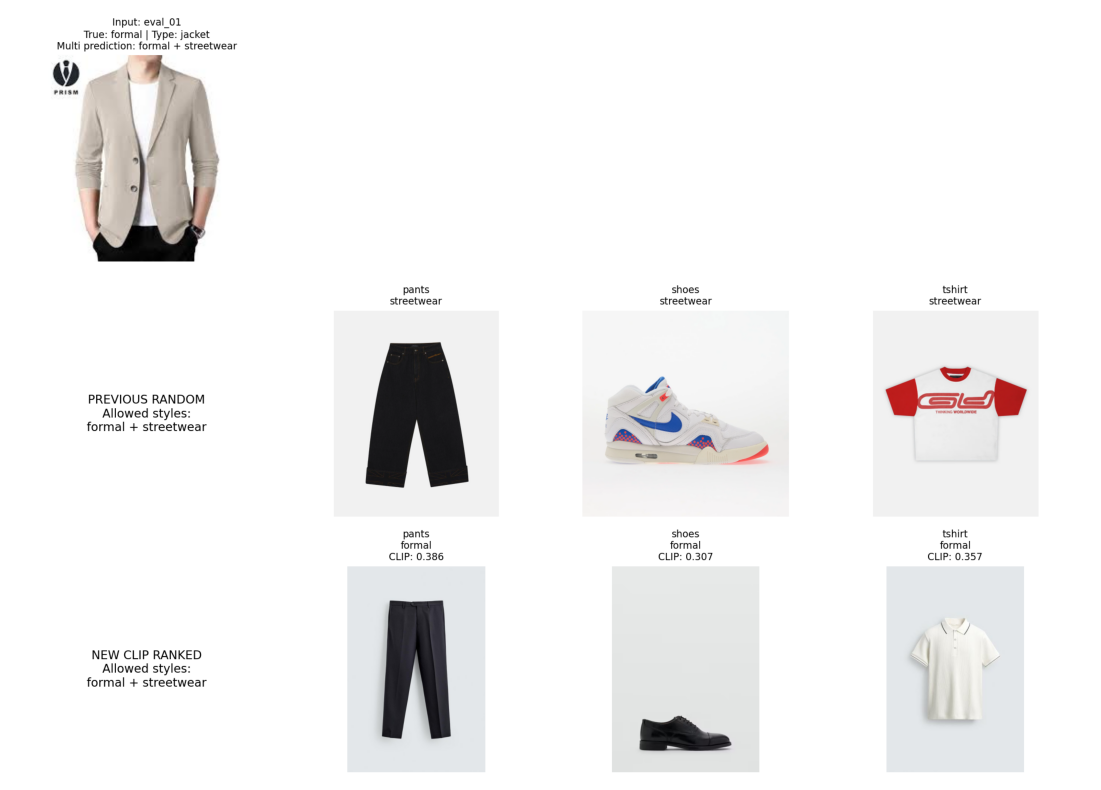

In [17]:
first_visual_sheet = saved_visual_sheets[0]

img = Image.open(first_visual_sheet)

plt.figure(figsize=(14, 10))
plt.imshow(img)
plt.axis("off")
plt.show()

## 17. Create CLIP Manual Scoring Sheet

Only the new CLIP-ranked recommendations are scored manually.

The previous random multi-style recommendations were already scored in the previous experiment, so their scores can be reused later for comparison.

This keeps the manual work smaller: only 16 rows need to be scored.

In [18]:
clip_scoring_rows = []

for _, row in clip_recommendation_df.iterrows():
    recommended_items_summary = []

    for item_type in target_types:
        style_col = f"{item_type}_style"
        filename_col = f"{item_type}_filename"
        similarity_col = f"{item_type}_clip_similarity"

        if style_col in row.index and pd.notna(row[style_col]):
            similarity_text = ""

            if similarity_col in row.index and pd.notna(row[similarity_col]):
                similarity_text = f" | CLIP similarity: {row[similarity_col]:.3f}"

            recommended_items_summary.append(
                f"{item_type}: {row[style_col]} - {row[filename_col]}{similarity_text}"
            )

    visual_sheet_path = visual_sheet_dir / f"{row['evaluation_id']}_random_vs_clip.png"

    clip_scoring_rows.append({
        "evaluation_id": row["evaluation_id"],
        "recommendation_mode": row["recommendation_mode"],
        "true_style": row["true_style"],
        "input_type": row["input_type"],
        "predicted_main_style": row["predicted_main_style"],
        "multi_label_prediction": row["predicted_styles_threshold_fallback"],
        "allowed_styles": row["allowed_styles"],

        "style_match_score": "",
        "type_match_score": "",
        "visual_coherence_score": "",
        "overall_quality_score": "",
        "manual_notes": "",

        "input_filename": row["filename"],
        "recommended_items": "\n".join(recommended_items_summary),
        "visual_sheet_path": str(visual_sheet_path),
        "input_image_path": row["input_image_path"]
    })

clip_manual_scoring_df = pd.DataFrame(clip_scoring_rows)

clip_scoring_template_path = manual_review_dir / "clip_manual_scoring_template.xlsx"
clip_scoring_template_csv_path = manual_review_dir / "clip_manual_scoring_template.csv"

clip_manual_scoring_df.to_excel(clip_scoring_template_path, index=False)
clip_manual_scoring_df.to_csv(clip_scoring_template_csv_path, index=False)

print("Saved CLIP scoring Excel to:", clip_scoring_template_path)
print("Saved CLIP scoring CSV to:", clip_scoring_template_csv_path)
print("Rows to score:", len(clip_manual_scoring_df))

display(clip_manual_scoring_df.head())

Saved CLIP scoring Excel to: ..\results\multilabel_clip_recommendation_ranking\manual_review\clip_manual_scoring_template.xlsx
Saved CLIP scoring CSV to: ..\results\multilabel_clip_recommendation_ranking\manual_review\clip_manual_scoring_template.csv
Rows to score: 16


,evaluation_id,recommendation_mode,true_style,input_type,predicted_main_style,multi_label_prediction,allowed_styles,style_match_score,type_match_score,visual_coherence_score,overall_quality_score,manual_notes,input_filename,recommended_items,visual_sheet_path,input_image_path
0,eval_01,new_multi_style_clip_ranked,formal,jacket,streetwear,formal + streetwear,formal + streetwear,,,,,,formal_jacket_rw_003.png,pants: formal - formal_pants_001.png | CLIP si...,..\results\multilabel_clip_recommendation_rank...,..\dataset\real_world_test\formal\jacket\forma...
1,eval_02,new_multi_style_clip_ranked,formal,tshirt,streetwear,formal + streetwear,formal + streetwear,,,,,,formal_tshirt_rw_002.png,jacket: formal - formal_jacket_015.png | CLIP ...,..\results\multilabel_clip_recommendation_rank...,..\dataset\real_world_test\formal\tshirt\forma...
2,eval_03,new_multi_style_clip_ranked,formal,tshirt,streetwear,sporty + streetwear,sporty + streetwear,,,,,,formal_tshirt_rw_003.png,jacket: sporty - sporty_jacket_023.png | CLIP ...,..\results\multilabel_clip_recommendation_rank...,..\dataset\real_world_test\formal\tshirt\forma...
3,eval_04,new_multi_style_clip_ranked,formal,tshirt,streetwear,sporty + streetwear,sporty + streetwear,,,,,,formal_tshirt_rw_005.png,jacket: sporty - sporty_jacket_038.png | CLIP ...,..\results\multilabel_clip_recommendation_rank...,..\dataset\real_world_test\formal\tshirt\forma...
4,eval_05,new_multi_style_clip_ranked,gothic,shoes,streetwear,gothic + sporty + streetwear,gothic + sporty + streetwear,,,,,,gothic_shoes_rw_002.png,jacket: gothic - gothic_jacket_020.png | CLIP ...,..\results\multilabel_clip_recommendation_rank...,..\dataset\real_world_test\gothic\shoes\gothic...


## 18. Load Completed CLIP Manual Scores

The CLIP-ranked recommendation scoring has now been completed.

This section loads the completed scoring sheet back into the notebook.

In [19]:
clip_completed_scoring_path = manual_review_dir / "clip_manual_scoring_completed.xlsx"

clip_scoring_completed_df = pd.read_excel(clip_completed_scoring_path)

print("Completed CLIP scoring file:", clip_completed_scoring_path)
print("Rows loaded:", len(clip_scoring_completed_df))
print("Columns:", clip_scoring_completed_df.columns.tolist())

display(clip_scoring_completed_df.head())

Completed CLIP scoring file: ..\results\multilabel_clip_recommendation_ranking\manual_review\clip_manual_scoring_completed.xlsx
Rows loaded: 16
Columns: ['evaluation_id', 'recommendation_mode', 'true_style', 'input_type', 'predicted_main_style', 'multi_label_prediction', 'allowed_styles', 'style_match_score', 'type_match_score', 'visual_coherence_score', 'overall_quality_score', 'manual_notes', 'input_filename', 'recommended_items', 'visual_sheet_path', 'input_image_path']


,evaluation_id,recommendation_mode,true_style,input_type,predicted_main_style,multi_label_prediction,allowed_styles,style_match_score,type_match_score,visual_coherence_score,overall_quality_score,manual_notes,input_filename,recommended_items,visual_sheet_path,input_image_path
0,eval_01,new_multi_style_clip_ranked,formal,jacket,streetwear,formal + streetwear,formal + streetwear,2,2,2,2,"Strong improvement. The formal pants, shoes, a...",formal_jacket_rw_003.png,pants: formal - formal_pants_001.png | CLIP si...,..\results\multilabel_clip_recommendation_rank...,..\dataset\real_world_test\formal\jacket\forma...
1,eval_02,new_multi_style_clip_ranked,formal,tshirt,streetwear,formal + streetwear,formal + streetwear,2,2,1,2,Formal recommendation fits the input better. T...,formal_tshirt_rw_002.png,jacket: formal - formal_jacket_015.png | CLIP ...,..\results\multilabel_clip_recommendation_rank...,..\dataset\real_world_test\formal\tshirt\forma...
2,eval_03,new_multi_style_clip_ranked,formal,tshirt,streetwear,sporty + streetwear,sporty + streetwear,1,2,2,1,"Visually coherent neutral sporty outfit, but i...",formal_tshirt_rw_003.png,jacket: sporty - sporty_jacket_023.png | CLIP ...,..\results\multilabel_clip_recommendation_rank...,..\dataset\real_world_test\formal\tshirt\forma...
3,eval_04,new_multi_style_clip_ranked,formal,tshirt,streetwear,sporty + streetwear,sporty + streetwear,1,2,1,1,"The sporty/streetwear outfit is usable, but it...",formal_tshirt_rw_005.png,jacket: sporty - sporty_jacket_038.png | CLIP ...,..\results\multilabel_clip_recommendation_rank...,..\dataset\real_world_test\formal\tshirt\forma...
4,eval_05,new_multi_style_clip_ranked,gothic,shoes,streetwear,gothic + sporty + streetwear,gothic + sporty + streetwear,2,2,2,2,"Strong gothic recommendation. Jacket, pants, a...",gothic_shoes_rw_002.png,jacket: gothic - gothic_jacket_020.png | CLIP ...,..\results\multilabel_clip_recommendation_rank...,..\dataset\real_world_test\gothic\shoes\gothic...


## 19. Validate CLIP Manual Scores

Before comparing results, the manual score columns are validated.

Each score should be between 0 and 2.

In [20]:
score_columns = [
    "style_match_score",
    "type_match_score",
    "visual_coherence_score",
    "overall_quality_score"
]

required_columns = [
    "evaluation_id",
    "recommendation_mode"
] + score_columns

missing_columns = [
    col for col in required_columns
    if col not in clip_scoring_completed_df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

for col in score_columns:
    clip_scoring_completed_df[col] = pd.to_numeric(
        clip_scoring_completed_df[col],
        errors="coerce"
    )

missing_score_rows = clip_scoring_completed_df[
    clip_scoring_completed_df[score_columns].isna().any(axis=1)
]

invalid_score_rows = clip_scoring_completed_df[
    ~clip_scoring_completed_df[score_columns].apply(
        lambda col: col.between(0, 2)
    ).all(axis=1)
]

print("Rows with missing scores:", len(missing_score_rows))
print("Rows with invalid scores:", len(invalid_score_rows))

if len(missing_score_rows) > 0:
    display(missing_score_rows[["evaluation_id", "recommendation_mode"] + score_columns])

if len(invalid_score_rows) > 0:
    display(invalid_score_rows[["evaluation_id", "recommendation_mode"] + score_columns])

clip_scoring_completed_df["total_score"] = clip_scoring_completed_df[score_columns].sum(axis=1)

display(
    clip_scoring_completed_df[
        ["evaluation_id", "recommendation_mode"] + score_columns + ["total_score"]
    ]
)

Rows with missing scores: 0
Rows with invalid scores: 0


,evaluation_id,recommendation_mode,style_match_score,type_match_score,visual_coherence_score,overall_quality_score,total_score
0,eval_01,new_multi_style_clip_ranked,2,2,2,2,8
1,eval_02,new_multi_style_clip_ranked,2,2,1,2,7
2,eval_03,new_multi_style_clip_ranked,1,2,2,1,6
3,eval_04,new_multi_style_clip_ranked,1,2,1,1,5
4,eval_05,new_multi_style_clip_ranked,2,2,2,2,8
5,eval_06,new_multi_style_clip_ranked,2,2,2,2,8
6,eval_07,new_multi_style_clip_ranked,2,2,2,2,8
7,eval_08,new_multi_style_clip_ranked,2,2,2,2,8
8,eval_09,new_multi_style_clip_ranked,1,2,1,1,5
9,eval_10,new_multi_style_clip_ranked,1,2,2,2,7


## 20. Load Previous Random Multi-Style Scores

The previous experiment already scored the random multi-style recommendations.

This section loads those previous scores so they can be compared against the new CLIP-ranked recommendations.

In [21]:
previous_completed_scoring_path = Path(
    "../results/multilabel_recommendation_evaluation/manual_review/recommendation_manual_scoring_completed.xlsx"
)

previous_scoring_completed_df = pd.read_excel(previous_completed_scoring_path)

previous_random_scores_df = previous_scoring_completed_df[
    previous_scoring_completed_df["recommendation_mode"] == "new_multi_style"
].copy()

previous_random_scores_df["recommendation_mode"] = "previous_random_multi_style"

for col in score_columns:
    previous_random_scores_df[col] = pd.to_numeric(
        previous_random_scores_df[col],
        errors="coerce"
    )

previous_random_scores_df["total_score"] = previous_random_scores_df[score_columns].sum(axis=1)

print("Previous random multi-style rows:", len(previous_random_scores_df))

display(
    previous_random_scores_df[
        ["evaluation_id", "recommendation_mode"] + score_columns + ["total_score"]
    ].head()
)

Previous random multi-style rows: 16


,evaluation_id,recommendation_mode,style_match_score,type_match_score,visual_coherence_score,overall_quality_score,total_score
1,eval_01,previous_random_multi_style,1,2,1,1,5
3,eval_02,previous_random_multi_style,0,2,0,0,2
5,eval_03,previous_random_multi_style,0,2,0,0,2
7,eval_04,previous_random_multi_style,0,2,0,0,2
9,eval_05,previous_random_multi_style,0,2,0,0,2


## 21. Compare Random Multi-Style and CLIP-Ranked Multi-Style

This section compares the average scores of the previous random multi-style recommendation mode and the new CLIP-ranked multi-style mode.

In [22]:
comparison_scores_df = pd.concat(
    [
        previous_random_scores_df[
            ["evaluation_id", "recommendation_mode"] + score_columns + ["total_score"]
        ],
        clip_scoring_completed_df[
            ["evaluation_id", "recommendation_mode"] + score_columns + ["total_score"]
        ]
    ],
    ignore_index=True
)

mode_summary = comparison_scores_df.groupby("recommendation_mode").agg(
    examples=("evaluation_id", "count"),
    avg_style_match=("style_match_score", "mean"),
    avg_type_match=("type_match_score", "mean"),
    avg_visual_coherence=("visual_coherence_score", "mean"),
    avg_overall_quality=("overall_quality_score", "mean"),
    avg_total_score=("total_score", "mean")
).reset_index()

display(mode_summary)

mode_summary_path = results_dir / "clip_vs_random_mode_score_summary.csv"
mode_summary.to_csv(mode_summary_path, index=False)

print("Saved mode summary to:", mode_summary_path)

,recommendation_mode,examples,avg_style_match,avg_type_match,avg_visual_coherence,avg_overall_quality,avg_total_score
0,new_multi_style_clip_ranked,16,1.6875,2.0,1.6875,1.8125,7.1875
1,previous_random_multi_style,16,1.0625,2.0,0.8750,1.0000,4.9375


Saved mode summary to: ..\results\multilabel_clip_recommendation_ranking\clip_vs_random_mode_score_summary.csv


## 22. Paired Comparison Per Input Image

Both recommendation modes are compared on the same 16 input images.

This shows how often the CLIP-ranked recommendation was better, worse, or equal compared with the random multi-style recommendation.

In [23]:
paired_scores = comparison_scores_df.pivot(
    index="evaluation_id",
    columns="recommendation_mode",
    values="total_score"
).reset_index()

paired_scores["score_difference_clip_minus_random"] = (
    paired_scores["new_multi_style_clip_ranked"] -
    paired_scores["previous_random_multi_style"]
)

paired_scores["comparison_result"] = paired_scores["score_difference_clip_minus_random"].apply(
    lambda diff: "clip_better" if diff > 0 else ("random_better" if diff < 0 else "equal")
)

display(paired_scores)

comparison_counts = paired_scores["comparison_result"].value_counts().reset_index()
comparison_counts.columns = ["comparison_result", "count"]

display(comparison_counts)

paired_scores_path = results_dir / "paired_clip_vs_random_score_comparison.csv"
paired_scores.to_csv(paired_scores_path, index=False)

print("Saved paired comparison to:", paired_scores_path)

recommendation_mode,evaluation_id,new_multi_style_clip_ranked,previous_random_multi_style,score_difference_clip_minus_random,comparison_result
0,eval_01,8,5,3,clip_better
1,eval_02,7,2,5,clip_better
2,eval_03,6,2,4,clip_better
3,eval_04,5,2,3,clip_better
4,eval_05,8,2,6,clip_better
5,eval_06,8,8,0,equal
6,eval_07,8,2,6,clip_better
7,eval_08,8,2,6,clip_better
8,eval_09,5,6,-1,random_better
9,eval_10,7,8,-1,random_better


,comparison_result,count
0,clip_better,11
1,random_better,3
2,equal,2


Saved paired comparison to: ..\results\multilabel_clip_recommendation_ranking\paired_clip_vs_random_score_comparison.csv


## 23. Save Final CLIP Recommendation Summary

This section saves the final result of the CLIP recommendation ranking experiment.

In [24]:
random_summary = mode_summary[
    mode_summary["recommendation_mode"] == "previous_random_multi_style"
].iloc[0]

clip_summary = mode_summary[
    mode_summary["recommendation_mode"] == "new_multi_style_clip_ranked"
].iloc[0]

final_clip_summary = {
    "experiment": "19_multilabel_clip_recommendation_ranking",
    "evaluated_examples": int(len(paired_scores)),
    "total_scored_rows": int(len(comparison_scores_df)),

    "random_avg_style_match": random_summary["avg_style_match"],
    "clip_avg_style_match": clip_summary["avg_style_match"],

    "random_avg_type_match": random_summary["avg_type_match"],
    "clip_avg_type_match": clip_summary["avg_type_match"],

    "random_avg_visual_coherence": random_summary["avg_visual_coherence"],
    "clip_avg_visual_coherence": clip_summary["avg_visual_coherence"],

    "random_avg_overall_quality": random_summary["avg_overall_quality"],
    "clip_avg_overall_quality": clip_summary["avg_overall_quality"],

    "random_avg_total_score": random_summary["avg_total_score"],
    "clip_avg_total_score": clip_summary["avg_total_score"],

    "avg_total_score_difference_clip_minus_random": (
        clip_summary["avg_total_score"] - random_summary["avg_total_score"]
    ),

    "clip_better_count": int((paired_scores["comparison_result"] == "clip_better").sum()),
    "random_better_count": int((paired_scores["comparison_result"] == "random_better").sum()),
    "equal_count": int((paired_scores["comparison_result"] == "equal").sum())
}

final_clip_summary_df = pd.DataFrame([final_clip_summary])

final_clip_summary_path = results_dir / "final_clip_recommendation_ranking_summary.csv"

final_clip_summary_df.to_csv(final_clip_summary_path, index=False)

print("Saved final CLIP recommendation summary to:", final_clip_summary_path)

display(final_clip_summary_df)

Saved final CLIP recommendation summary to: ..\results\multilabel_clip_recommendation_ranking\final_clip_recommendation_ranking_summary.csv


,experiment,evaluated_examples,total_scored_rows,random_avg_style_match,clip_avg_style_match,random_avg_type_match,clip_avg_type_match,random_avg_visual_coherence,clip_avg_visual_coherence,random_avg_overall_quality,clip_avg_overall_quality,random_avg_total_score,clip_avg_total_score,avg_total_score_difference_clip_minus_random,clip_better_count,random_better_count,equal_count
0,19_multilabel_clip_recommendation_ranking,16,32,1.0625,1.6875,2.0,2.0,0.875,1.6875,1.0,1.8125,4.9375,7.1875,2.25,11,3,2


## 24. Compare All Recommendation Approaches

This section compares the three recommendation approaches tested across the recent experiments:

1. old single-style recommendation
2. random multi-style recommendation
3. multi-style recommendation with CLIP ranking

This helps show the full improvement path.

In [25]:
all_recommendation_comparison = pd.DataFrame([
    {
        "recommendation_approach": "old_single_style",
        "description": "Uses only the main predicted style",
        "avg_style_match": 1.0625,
        "avg_type_match": 2.0,
        "avg_visual_coherence": 1.125,
        "avg_overall_quality": 1.3125,
        "avg_total_score": 5.5000
    },
    {
        "recommendation_approach": "random_multi_style",
        "description": "Uses multi-label styles but selects items randomly",
        "avg_style_match": 1.0625,
        "avg_type_match": 2.0,
        "avg_visual_coherence": 0.8750,
        "avg_overall_quality": 1.0000,
        "avg_total_score": 4.9375
    },
    {
        "recommendation_approach": "clip_ranked_multi_style",
        "description": "Uses multi-label styles and ranks items with CLIP similarity",
        "avg_style_match": 1.6875,
        "avg_type_match": 2.0,
        "avg_visual_coherence": 1.6875,
        "avg_overall_quality": 1.8125,
        "avg_total_score": 7.1875
    }
])

display(all_recommendation_comparison)

all_recommendation_comparison_path = results_dir / "all_recommendation_approaches_comparison.csv"

all_recommendation_comparison.to_csv(
    all_recommendation_comparison_path,
    index=False
)

print("Saved all recommendation comparison to:", all_recommendation_comparison_path)

,recommendation_approach,description,avg_style_match,avg_type_match,avg_visual_coherence,avg_overall_quality,avg_total_score
0,old_single_style,Uses only the main predicted style,1.0625,2.0,1.1250,1.3125,5.5000
1,random_multi_style,Uses multi-label styles but selects items rand...,1.0625,2.0,0.8750,1.0000,4.9375
2,clip_ranked_multi_style,Uses multi-label styles and ranks items with C...,1.6875,2.0,1.6875,1.8125,7.1875


Saved all recommendation comparison to: ..\results\multilabel_clip_recommendation_ranking\all_recommendation_approaches_comparison.csv


## 25. Result Interpretation

The results show that CLIP ranking clearly improved the recommendation quality.

The previous random multi-style recommendation mode achieved an average total score of 4.94. After adding CLIP ranking, the average total score increased to 7.19. This is an improvement of 2.25 points on an 8-point scale.

The improvement is mainly visible in:

- style match
- visual coherence
- overall quality

The type match score stayed the same because all recommendation modes already selected the correct missing clothing types.

The paired comparison also supports the improvement. CLIP-ranked recommendations were better in 11 out of 16 examples, random recommendations were better in only 3 examples, and 2 examples were equal.

This means the problem in the previous experiment was not the multi-label style prediction itself. The problem was the random item selection. Once CLIP ranking was added, the multi-label style predictions became much more useful for producing coherent outfit recommendations.

## 26. Final Conclusion

This experiment tested whether CLIP visual similarity ranking improves multi-label outfit recommendations.

The previous experiment showed that simply allowing multiple predicted styles into the recommendation pool did not improve the recommendation quality. The random multi-style approach achieved an average total score of 4.94, which was lower than the old single-style recommendation mode.

In this experiment, the same multi-label style predictions were used, but the final item selection was changed. Instead of randomly selecting items from the allowed style pool, the system ranked candidate items using CLIP image similarity and selected the most visually similar items for each missing clothing type.

This produced a clear improvement. The CLIP-ranked multi-style recommendation mode achieved an average total score of 7.19, compared with 4.94 for the random multi-style mode. CLIP-ranked recommendations were better in 11 out of 16 examples, worse in 3 examples, and equal in 2 examples.

The strongest improvements were in visual coherence and overall quality. This shows that multi-label style prediction becomes useful when it is combined with a stronger ranking step. Multi-label prediction gives the system more possible style directions, while CLIP ranking helps choose items that visually fit the uploaded clothing item.

The main conclusion is that the final recommendation system should not use multi-label prediction as a simple filter only. The best approach is to combine multi-label style prediction with CLIP-based visual ranking. This gives the system both flexible style understanding and better outfit coherence.